In [1]:
import sys
import scanpy as sc
import pandas as pd
from cnmf import cNMF
import numpy as np
import tqdm as tqdm
import pandas as pd
import gseapy as gp
from tqdm.auto import tqdm

user-indicated parameters

In [10]:
input_cnmf_pathway = "ml_program/adatafinal22"      #filepath to cnmf run
input_cnmf_run_name = "k22run"                      #name of cnmf run
k_programs = 22                                     #number of programs (k) you want to test
verbose = True                                      #verbose?
ORA_TOP_N_GENES = 300                               #what number of genes belong to a program in ORA
save_output_path = 'p22_data/'                      #what path do you wan the results to save to

FileNotFoundError: [Errno 2] No such file or directory: 'data/anish_programs/20250630_allgenes_20iter_HQ_k15to200.gene_spectra_score.k_60.dt_0_55.txt'

choose biological dataset to compare with

In [ ]:
gene_sets_db = "GO_Biological_Process_2023"
#gene_sets_db = "KEGG_2021_Human"
#gene_sets_db = 'MSigDB_Hallmark_2020'

gene_set_name = gene_sets_db.split('_')[0]

/hpc/home/zy231/.local/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


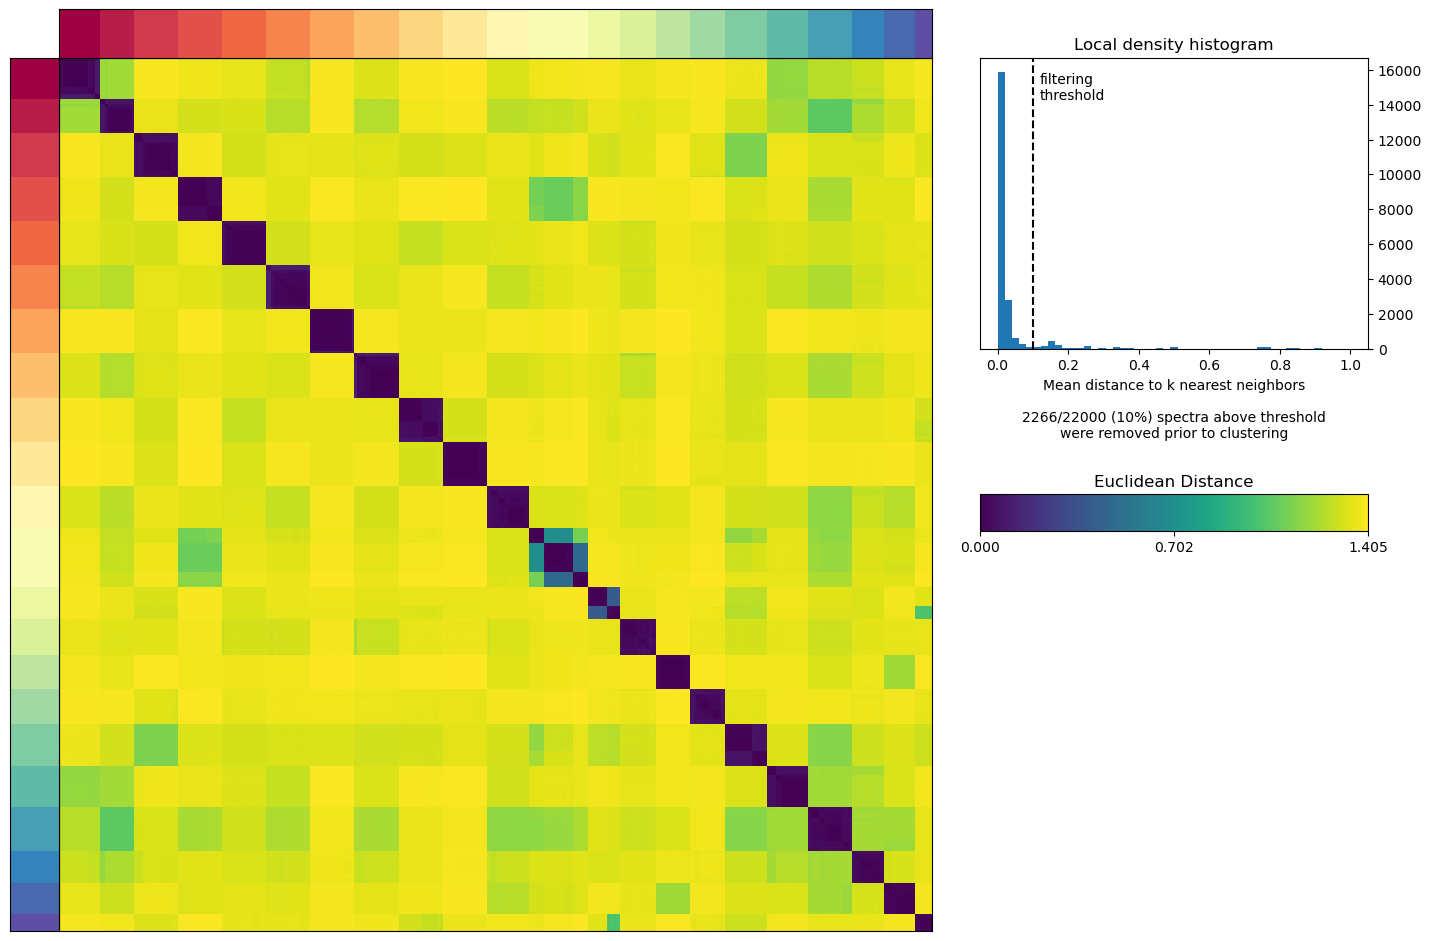

In [ ]:
cnmf_obj = cNMF(output_dir=input_cnmf_pathway, name=input_cnmf_run_name)
cnmf_obj.consensus(k=k_programs, density_threshold=0.1)
usage, spectra_scores, spectra_tpm, top_genes = cnmf_obj.load_results(K=k_programs, density_threshold=0.1)

### GSEA

In [ ]:
all_gsea_results = {}

for i in tqdm(range(1,k_programs+1)):
    print(f"\n--- Running Program {i} of {k_programs} ---")
        

    program_ranked_list = spectra_scores[i].sort_values(ascending=False)
        

    prerank_df = pd.DataFrame(program_ranked_list)
    prerank_df.reset_index(inplace=True)
    prerank_df.columns = ['gene', 'score']
        

    try:
        prerank_results = gp.prerank(
            rnk=prerank_df,
            gene_sets=gene_sets_db,
            min_size=15,
            max_size=500,
            threads = -1,
            permutations = 1000,
            outdir=None,
            seed = 6,
            verbose = verbose,
        )
            

        if not prerank_results.res2d.empty:
            print(f"Program {i} - Top hit: {prerank_results.res2d.iloc[0]['Term']}")
            all_gsea_results[i] = prerank_results.res2d
        else:
            print(f"Program {i} - No significant pathways found.")
                
    except Exception as e:
        print(f"Error processing Program {i}: {e}")
    
print("Looping through results dictionary to build summary table...")


  0%|          | 0/22 [00:00<?, ?it/s]

2026-02-16 23:24:15,720 [WARNING] Duplicated values found in preranked stats: 27.12% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-02-16 23:24:15,722 [INFO] Parsing data files for GSEA.............................
2026-02-16 23:24:15,780 [INFO] Enrichr library gene sets already downloaded in: /hpc/home/zy231/.cache/gseapy, use local file



--- Running Program 1 of 22 ---


2026-02-16 23:24:15,970 [INFO] 2695 gene_sets have been filtered out when max_size=500 and min_size=15
2026-02-16 23:24:15,973 [INFO] 2712 gene_sets used for further statistical testing.....
2026-02-16 23:24:15,974 [INFO] Start to run GSEA...Might take a while..................
2026-02-16 23:34:08,322 [INFO] Congratulations. GSEApy runs successfully................

2026-02-16 23:34:08,476 [WARNING] Duplicated values found in preranked stats: 27.12% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-02-16 23:34:08,477 [INFO] Parsing data files for GSEA.............................
2026-02-16 23:34:08,553 [INFO] Enrichr library gene sets already downloaded in: /hpc/home/zy231/.cache/gseapy, use local file


Program 1 - Top hit: Translation (GO:0006412)

--- Running Program 2 of 22 ---


...

Program 20 - Top hit: Cytoplasmic Translation (GO:0002181)

--- Running Program 21 of 22 ---


2026-02-17 02:41:11,197 [INFO] 2695 gene_sets have been filtered out when max_size=500 and min_size=15
2026-02-17 02:41:11,201 [INFO] 2712 gene_sets used for further statistical testing.....
2026-02-17 02:41:11,202 [INFO] Start to run GSEA...Might take a while..................
2026-02-17 02:51:01,721 [INFO] Congratulations. GSEApy runs successfully................

2026-02-17 02:51:02,804 [WARNING] Duplicated values found in preranked stats: 27.12% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-02-17 02:51:02,806 [INFO] Parsing data files for GSEA.............................
2026-02-17 02:51:02,894 [INFO] Enrichr library gene sets already downloaded in: /hpc/home/zy231/.cache/gseapy, use local file


Program 21 - Top hit: Aerobic Electron Transport Chain (GO:0019646)

--- Running Program 22 of 22 ---


2026-02-17 02:51:03,026 [INFO] 2695 gene_sets have been filtered out when max_size=500 and min_size=15
2026-02-17 02:51:03,029 [INFO] 2712 gene_sets used for further statistical testing.....
2026-02-17 02:51:03,031 [INFO] Start to run GSEA...Might take a while..................
2026-02-17 03:00:51,275 [INFO] Congratulations. GSEApy runs successfully................



Program 22 - Top hit: Cytoplasmic Translation (GO:0002181)
Looping through results dictionary to build summary table...


In [ ]:
t5_pathways_list = []
fdr25_pathways_list = []
fdr5_pathways_list = []


for program_name, results_df in all_gsea_results.items():
    

    if results_df.empty:
        continue
    
    sorted_df = results_df.sort_values(by='NES', ascending=False)

    top_5 = results_df.sort_values(by = 'FDR q-val', ascending = True).head(5)
    fdr25 = sorted_df[sorted_df['FDR q-val'] <= 0.25]
    fdr5 = sorted_df[sorted_df['FDR q-val'] <= 0.05]
    

    top_5.insert(0, 'Program_ID', program_name)
    fdr25.insert(0, 'Program_ID', program_name)
    fdr5.insert(0, 'Program_ID', program_name)
    

    t5_pathways_list.append(top_5) 
    fdr25_pathways_list.append(fdr25)
    fdr5_pathways_list.append(fdr5)


t5_summary = pd.concat(t5_pathways_list, ignore_index=True)
fdr25_summary = pd.concat(fdr25_pathways_list, ignore_index=True)
fdr5_summary = pd.concat(fdr5_pathways_list, ignore_index=True)

print("Saving summary DataFrame to CSV...")
t5_summary.to_csv(save_output_path + gene_set_name + '_t5_gsea.csv', index=False)
fdr25_summary.to_csv(save_output_path + gene_set_name +'_f25_gsea.csv', index=False)
fdr5_summary.to_csv(save_output_path + gene_set_name +'_f5_gsea.csv', index=False)



✅ GSEA complete for all programs!
Saving summary DataFrame to CSV...


### ORA

In [ ]:
all_ora_results = {}

for i in tqdm(range(1, chosen_k+1 )):
    print(f"--- Running ORA on Program {i} of {chosen_k} ---")
    
    program_gene_list = top_genes[i].head(N_TOP_GENES).tolist()
    
    try:
        enr_results = gp.enrichr(
            gene_list=program_gene_list,
            gene_sets=gene_sets_db,
            outdir=None,
            cutoff=0.05 
        )
        
        if not enr_results.res2d.empty:
            print(f"Program {i} - Top hit: {enr_results.res2d.iloc[0]['Term']}")
            all_ora_results[i] = enr_results.res2d
        else:
            print(f"Program {i} - No significant pathways found.")
            
    except Exception as e:
        print(f"Error processing Program {i}: {e}")

In [ ]:
t5_pathways = []
p5_pathways = []
for program_name, results_df in all_ora_results.items():
    if not results_df.empty:
        
        t5_hits = results_df.iloc[:5].copy()
        t5_hits.insert(0, 'Program', program_name)
        t5_hits = t5_hits.rename(columns={'Term': 'Top_Pathway', 'Adjusted P-value': 'Adj_P-value', 'Combined Score': 'Combined_Score'})
        t5_hits.sort_values('Adj_P-value')
        t5_pathways.append(t5_hits)

        p5_hits = results_df[results_df['Adjusted P-value'] <= 0.05].copy()
        p5_hits.insert(0, 'Program', program_name)
        p5_hits = p5_hits.rename(columns={'Term': 'Top_Pathway', 'Adjusted P-value': 'Adj_P-value', 'Combined Score': 'Combined_Score'})
        p5_hits.sort_values('Adj_P-value')
        p5_pathways.append(p5_hits)

t5_summary = pd.concat(t5_pathways, ignore_index=True)
p5_summary = pd.concat(p5_pathways, ignore_index=True)


t5_summary.to_csv(path + gene_set_name + '_t5_ora.csv', index=False)
p5_summary.to_csv(path + gene_set_name + '_p5_ora.csv', index=False)

print("--- Pipeline Complete ---")